Выборочное среднее: 5.905377573899554
Выборочная дисперсия: 11.767106561170456


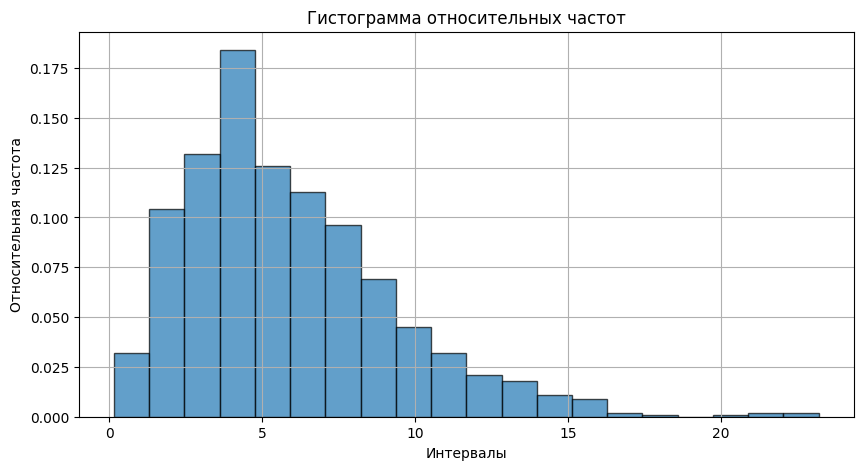

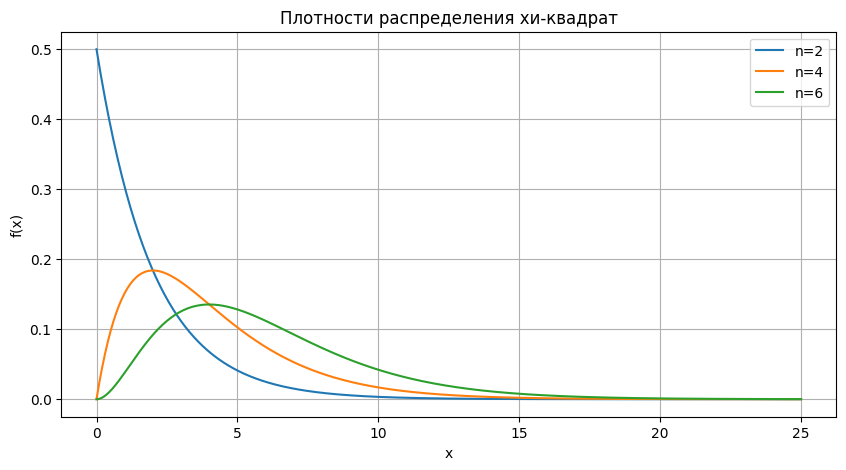

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import chi2

#Количество наблюдений
N = 1000

#генерируем N строк по 6 нормальных случайных величин
xi = np.random.normal(0, 1, size=(N, 6))

#ν = ξ1^2 + ... + ξ6^2
nu = np.sum(xi ** 2, axis=1)

#выборочное среднее
sample_mean = np.mean(nu)

#выборочная дисперсия
sample_variance = np.var(nu, ddof=1)

print("Выборочное среднее:", sample_mean)
print("Выборочная дисперсия:", sample_variance)

# Число интервалов
k = 20

bins = np.linspace(np.min(nu), np.max(nu), k + 1)

counts, edges = np.histogram(nu, bins=bins)

#относительные частоты
relative_freq = counts / N

widths = np.diff(edges)

left_edges = edges[:-1]

plt.figure(figsize=(10, 5))
plt.bar(left_edges, relative_freq, width=widths, align='edge', edgecolor='black', alpha=0.7)

plt.title("Гистограмма относительных частот")
plt.xlabel("Интервалы")
plt.ylabel("Относительная частота")
plt.grid(True)
plt.show()

#графики плотности
x = np.linspace(0, 25, 500)

plt.figure(figsize=(10, 5))
plt.plot(x, chi2.pdf(x, df=2), label='n=2')
plt.plot(x, chi2.pdf(x, df=4), label='n=4')
plt.plot(x, chi2.pdf(x, df=6), label='n=6')

plt.title("Плотности распределения хи-квадрат")
plt.xlabel("x")
plt.ylabel("f(x)")
plt.legend()
plt.grid(True)
plt.show()

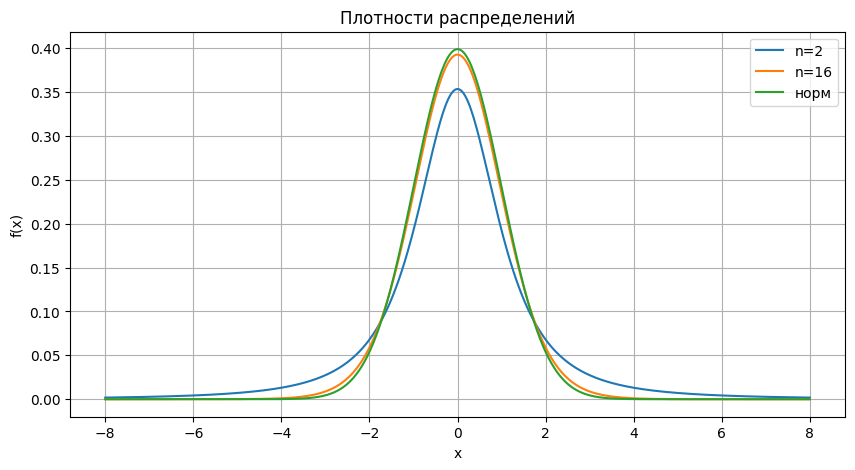

Выборочное среднее: -0.03911841636745219
Выборочная дисперсия: 1.1814145170353927


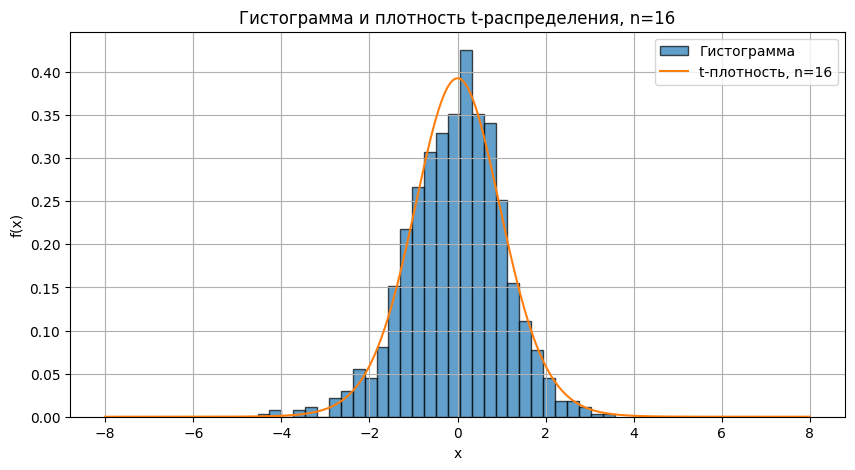

In [3]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import t, norm

x = np.linspace(-8, 8, 500)

#плотности
y_t2 = t.pdf(x, df=2)
y_t16 = t.pdf(x, df=16)
y_norm = norm.pdf(x)

#график плотностей
plt.figure(figsize=(10, 5))
plt.plot(x, y_t2, label='n=2')
plt.plot(x, y_t16, label='n=16')
plt.plot(x, y_norm, label='норм')

plt.title('Плотности распределений')
plt.xlabel('x')
plt.ylabel('f(x)')
plt.legend()
plt.grid(True)
plt.show()

# Моделирование t-распределения
n = 16
N = 1000

# ξ ~ N(0,1)
xi = np.random.normal(0, 1, N)

# η ~ χ²(n)
normal_matrix = np.random.normal(0, 1, (N, n))
eta = np.sum(normal_matrix ** 2, axis=1)

#случайная величина Стьюдента
t_sample = xi / np.sqrt(eta / n)

sample_mean = np.mean(t_sample)
sample_variance = np.var(t_sample, ddof=1)

print("Выборочное среднее:", sample_mean)
print("Выборочная дисперсия:", sample_variance)

#гистограмма
plt.figure(figsize=(10, 5))
plt.hist(t_sample, bins=30, density=True, alpha=0.7, edgecolor='black', label='Гистограмма')
plt.plot(x, t.pdf(x, df=n), label=f't-плотность, n={n}')

plt.title(f'Гистограмма и плотность t-распределения, n={n}')
plt.xlabel('x')
plt.ylabel('f(x)')
plt.legend()
plt.grid(True)
plt.show()

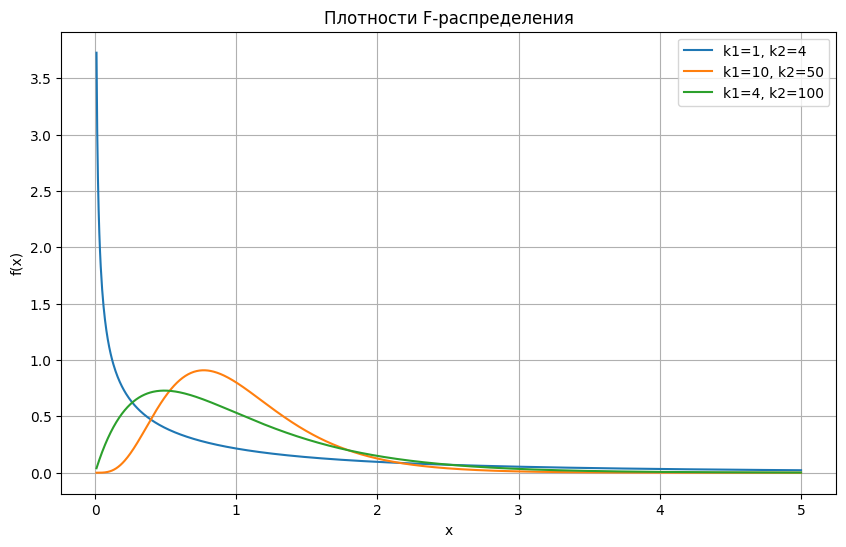

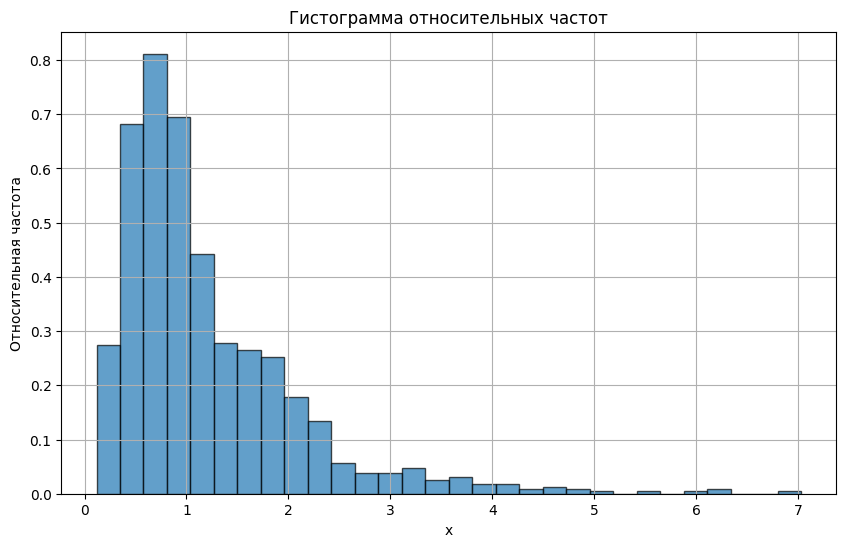

Выборочное среднее = 1.1992390365690853
Выборочная дисперсия = 0.7829806073445735
Коэффициент асимметрии = 2.1490786208135693


In [3]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import f, skew

#графики плотности F-распределения

x = np.linspace(0.01, 5, 1000)

k_values = [
    (1, 4),
    (10, 50),
    (4, 100)
]

plt.figure(figsize=(10, 6))

for k1, k2 in k_values:
    y = f.pdf(x, dfn=k1, dfd=k2)
    plt.plot(x, y, label=f'k1={k1}, k2={k2}')

plt.title('Плотности F-распределения')
plt.xlabel('x')
plt.ylabel('f(x)')
plt.legend()
plt.grid(True)
plt.show()

# через хи-квадрат распределения

N = 1000#количество наблюдений
n = 10#число степеней свободы для хи-квадрат

#независимые случайные величины
xi1 = np.random.chisquare(df=n, size=N)
xi2 = np.random.chisquare(df=n, size=N)

#F-распределение:
sample = (xi1 / n) / (xi2 / n)

plt.figure(figsize=(10, 6))
plt.hist(sample, bins=30, density=True, alpha=0.7, edgecolor='black')
plt.title('Гистограмма относительных частот')
plt.xlabel('x')
plt.ylabel('Относительная частота')
plt.grid(True)
plt.show()

sample_mean = np.mean(sample)
sample_variance = np.var(sample, ddof=1)
sample_skewness = skew(sample, bias=False)

print('Выборочное среднее =', sample_mean)
print('Выборочная дисперсия =', sample_variance)
print('Коэффициент асимметрии =', sample_skewness)

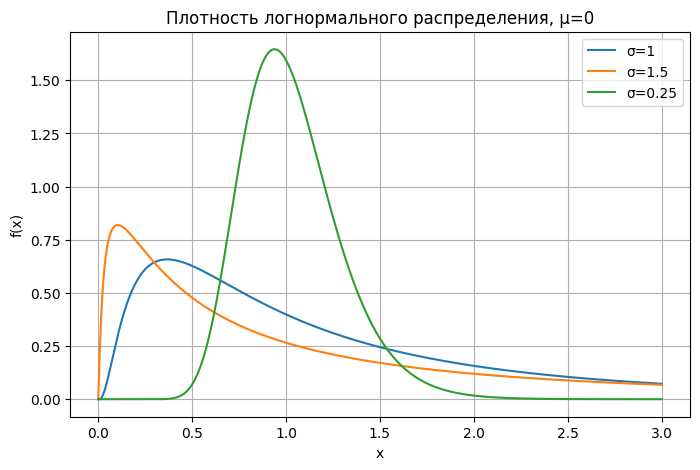

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import lognorm

mu = 0#параметры
sigma_values = [1, 1.5, 0.25]

x = np.linspace(0.001, 3, 1000)

plt.figure(figsize=(8,5))

for sigma in sigma_values:
    y = lognorm.pdf(x, s=sigma, scale=np.exp(mu))
    plt.plot(x, y, label=f'σ={sigma}')

plt.title('Плотность логнормального распределения, μ=0')
plt.xlabel('x')
plt.ylabel('f(x)')
plt.legend()
plt.grid()

plt.show()

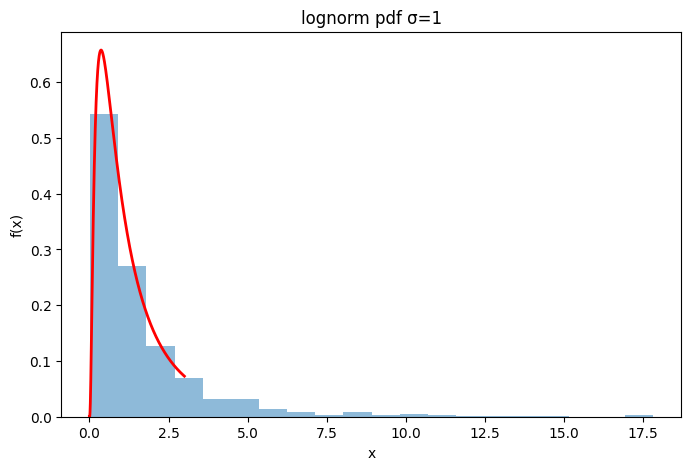

In [5]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import lognorm

#параметры
mu = 0
sigma = 1
N = 1000

#генерируем выборку
data = np.random.lognormal(mean=mu, sigma=sigma, size=N)

x = np.linspace(0.001, 3, 1000)
pdf = lognorm.pdf(x, s=sigma, scale=np.exp(mu))

plt.figure(figsize=(8,5))

plt.hist(data, bins=20, density=True, alpha=0.5)
plt.plot(x, pdf, 'r', linewidth=2)

plt.title("lognorm pdf σ=1")
plt.xlabel("x")
plt.ylabel("f(x)")

plt.show()